# 2. Does expiry make the market jumpier?

**The question:** on days when an index's options expire, is the index more volatile? Volatility means how much the price swings.

**How we measure volatility**
- **Whole day:** the Garman–Klass estimate, which uses the day's open, high, low and close. Also realized variance from 5-minute returns.
- **Settlement window:** the variance of 1-minute returns from 15:00 to 15:30. Until August 2026, the official closing value (the settlement price of expiring options) was the average price of this half hour.

**How we compare (the "fixed effects")**
- We compare each expiry day with *the same index, in the same week*. This removes calm weeks versus crisis weeks.
- We also compare it with *the usual level of that weekday* for that index (for example, Mondays are often jumpier).
- So the comparison only works because the calendar *changed*. That is the natural experiment.

**Reading the numbers:** a coefficient of 0.10 on log variance is roughly a 10% higher variance (about 5% higher volatility). We convert with `pct()`.

In [1]:
import sys, warnings
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
from IPython.display import Image, display
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 20)
from expiryvol import data, expiries as ex, estimate as es, mechanisms as me, forecast as fc, plots
from expiryvol.features import build_panel
DATA, RES, FIG = ROOT / "data", ROOT / "results", ROOT / "figures"
pct = lambda b: 100 * (np.exp(b) - 1)   # log-variance difference -> % change in variance

In [2]:
prices, dropped = data.load_all_daily(DATA)          # downloads from Yahoo on the first run
td = data.trading_days("2013-06-03", data.DATA_END)  # exchange trading days (holiday list in expiryvol/holidays.py)
table = ex.expiry_table(td)                          # which option product expires on which day
panel = build_panel(prices, table, data.INDICES, data.STUDY_START, data.STUDY_END)
print(f"{len(panel):,} index-days, {panel['date'].min().date()} to {panel['date'].max().date()}")

12,312 index-days, 2014-01-01 to 2026-07-31


## Result 1: the whole trading day is at most slightly more volatile on expiry days
- Pooled over the four indices, weekly expiry days are about as volatile as other days.
- The 95% interval rules out more than a ~4% rise in variance.
- Only Nifty's weekly expiry days stand out, and they are a little *calmer*.

In [3]:
main = es.main_regressions(panel, "lgk")
show = main.assign(change_pct=pct(main["coef"]).round(1))[["sample", "term", "coef", "se", "p", "p_holm", "change_pct", "n"]]
show.round(3)

,sample,term,coef,se,p,p_holm,change_pct,n
0,pooled,own_weekly,-0.024,0.032,0.457,NaN,-2.4,12312
1,pooled,own_monthly,0.055,0.049,0.257,NaN,5.7,12312
2,pooled,other_major,-0.062,0.034,0.073,NaN,-6.0,12312
3,pooled,other_minor,-0.094,0.048,0.051,NaN,-9.0,12312
4,banknifty,own_weekly,-0.019,0.058,0.738,1.000,-1.9,3090
5,banknifty,own_monthly,-0.001,0.078,0.993,1.000,-0.1,3090
6,banknifty,other_major,-0.001,0.049,0.981,0.981,-0.1,3090
7,banknifty,other_minor,-0.052,0.052,0.310,0.620,-5.1,3090
8,midcap50,own_weekly,-0.033,0.097,0.738,1.000,-3.2,3056
9,midcap50,own_monthly,-0.082,0.111,0.461,1.000,-7.9,3056


## Result 2: the last 30 minutes ARE much more volatile on expiry days
- We use 1-minute bars for Nifty and Bank Nifty (May 2021 – Jul 2026) and Sensex (Sep 2022 – Jul 2026).
- Same comparison as above.

In [4]:
mdays, slots = me.minute_panels(table, DATA, end=data.STUDY_END)
md_tab = me.day_effects(mdays, ("lrv5", "lrv_last"))
md_tab.assign(change_pct=pct(md_tab["coef"]).round(0))[["outcome", "sample", "term", "coef", "se", "p", "change_pct"]].round(3)

,outcome,sample,term,coef,se,p,change_pct
0,lrv5,pooled,own_weekly,0.019,0.036,0.595,2.0
1,lrv5,pooled,own_monthly,0.095,0.058,0.105,10.0
2,lrv5,pooled,other_major,0.012,0.036,0.738,1.0
3,lrv5,pooled,other_minor,-0.089,0.044,0.046,-8.0
4,lrv5,banknifty,own_weekly,0.018,0.057,0.756,2.0
5,lrv5,banknifty,own_monthly,-0.010,0.085,0.904,-1.0
6,lrv5,banknifty,other_major,0.043,0.048,0.373,4.0
7,lrv5,banknifty,other_minor,-0.046,0.043,0.287,-5.0
8,lrv5,nifty50,own_weekly,-0.051,0.056,0.361,-5.0
9,lrv5,nifty50,own_monthly,0.176,0.089,0.050,19.0


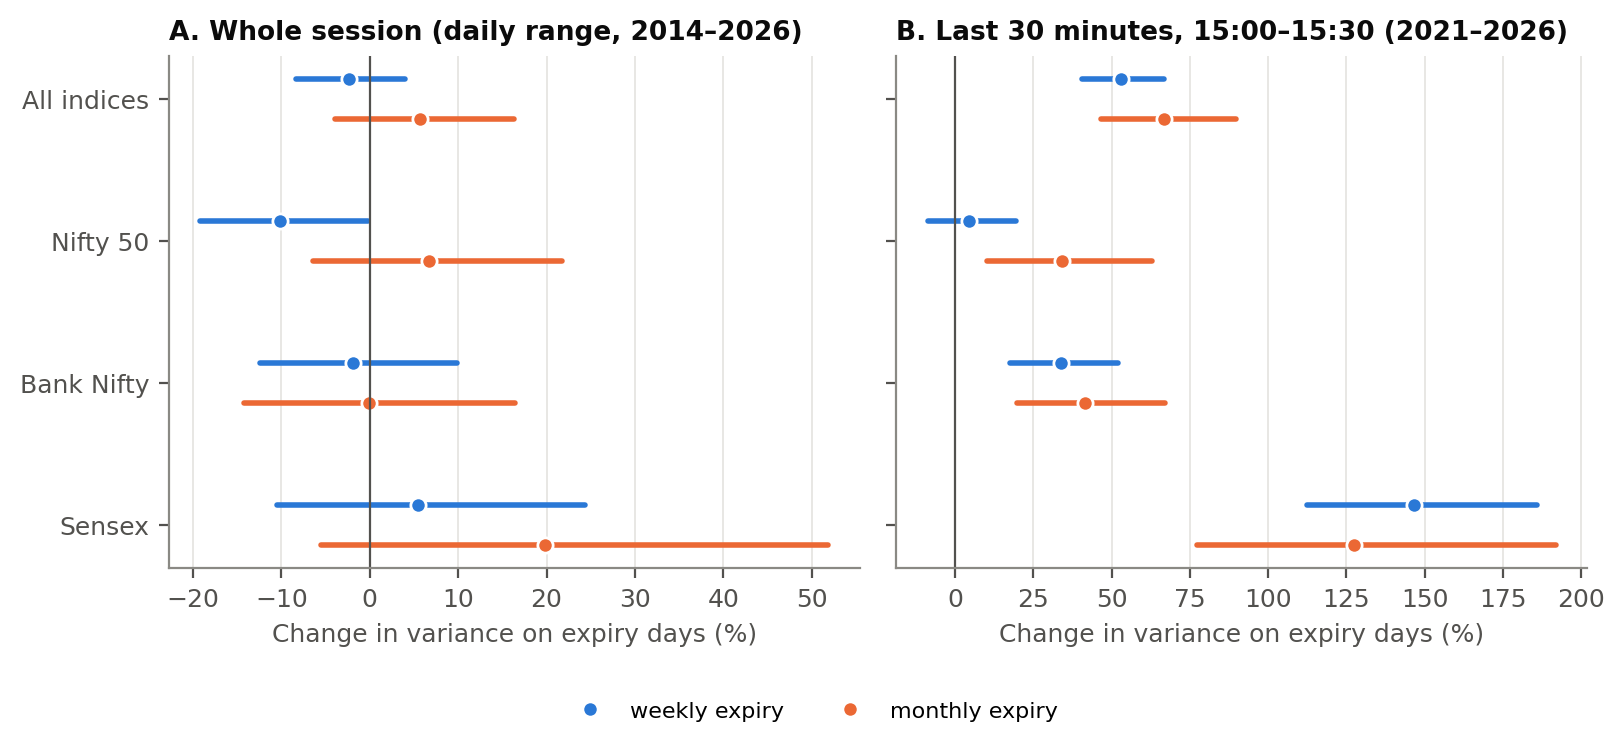

In [5]:
Image(FIG / 'fig3_main.png')

## Result 3: when the expiry day moves, the jumpy last half hour moves with it
This is the natural experiment.
- Each panel shows one calendar change. The grey bars are 6 months before it, the blue bars 6 months after.
- Each bar is the last-30-minute variance on that weekday, relative to the rest of its week.
- The spike appears on the new expiry day in every change. Example: Sensex moved Friday → Tuesday (Jan 2025) and then Tuesday → Thursday (Sep 2025).
- The old weekday calms down in four of the five changes that removed an expiry. The exception is Nifty's Thursday, which got Sensex's expiry on the same day.

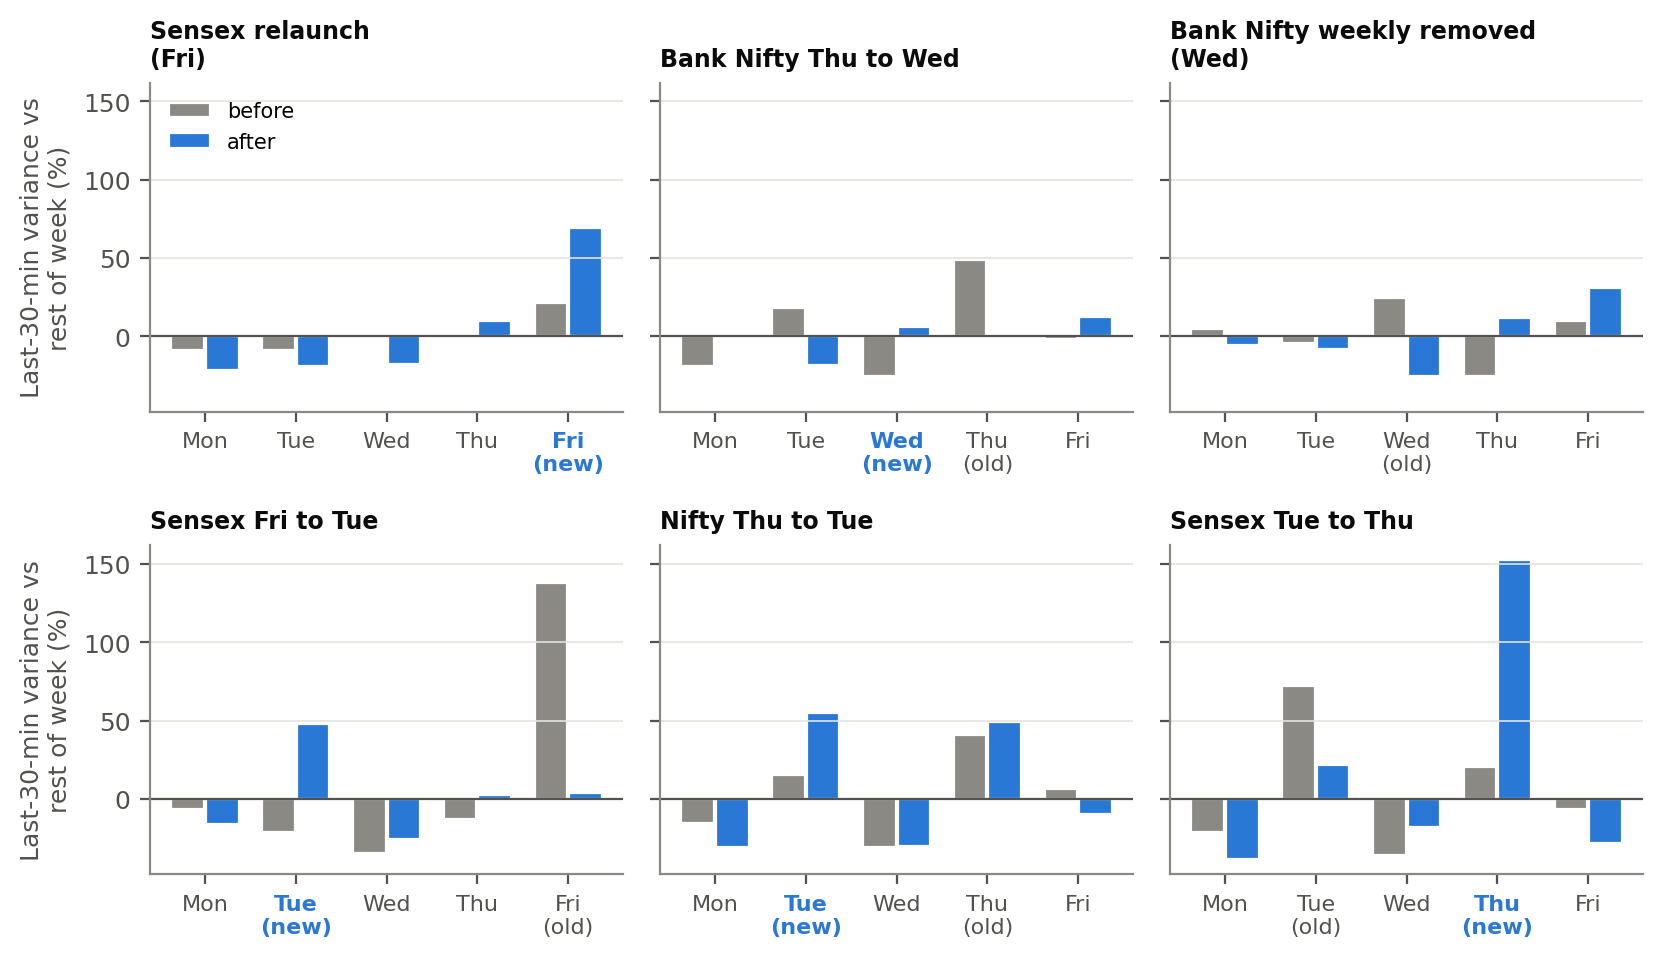

In [6]:
Image(FIG / 'fig2_moving_close.png')

Difference-in-differences for each change:
- `gain_post` is the change in the new expiry weekday after the switch, compared with the other weekdays.
- `lose_post` is the same for the old weekday.

In [7]:
ev = pd.read_csv(RES / "event_did.csv")
ev[ev["outcome"] == "lrv_last"][["event", "date", "term", "coef", "se", "p"]].round(3)

,event,date,term,coef,se,p
4,Sensex relaunch (Fri),2023-05-15,gain_post,0.424,0.194,0.034
10,Bank Nifty Thu to Wed,2023-09-04,gain_post,0.332,0.201,0.104
11,Bank Nifty Thu to Wed,2023-09-04,lose_post,-0.370,0.177,0.042
16,Bank Nifty weekly removed (Wed),2024-11-20,lose_post,-0.730,0.209,0.001
20,Sensex Fri to Tue,2025-01-04,gain_post,0.549,0.185,0.004
21,Sensex Fri to Tue,2025-01-04,lose_post,-0.913,0.189,0.000
26,Nifty Thu to Tue,2025-09-01,gain_post,0.412,0.187,0.032
27,Nifty Thu to Tue,2025-09-01,lose_post,0.181,0.198,0.363
32,Sensex Tue to Thu,2025-09-01,gain_post,0.864,0.187,0.000
33,Sensex Tue to Thu,2025-09-01,lose_post,-0.239,0.200,0.238


In [8]:
pd.read_csv(RES / 'event_stacked.csv').round(3)

,term,coef,se,t,p,lo,hi,n,events,outcome,design
0,gain_post,0.145,0.081,1.801,0.073,-0.014,0.304,1863,8,lgk,"8 major events, daily range"
1,lose_post,-0.016,0.134,-0.121,0.904,-0.279,0.247,1863,8,lgk,"8 major events, daily range"
2,gain_post,0.116,0.097,1.195,0.234,-0.075,0.306,1380,6,lgk,"6 events with minute data, daily range"
3,lose_post,-0.023,0.137,-0.170,0.865,-0.294,0.247,1380,6,lgk,"6 events with minute data, daily range"
4,gain_post,0.143,0.069,2.067,0.040,0.006,0.280,1366,6,lrv5,"6 events, whole session (5-min RV)"
5,lose_post,-0.038,0.098,-0.389,0.698,-0.233,0.156,1366,6,lrv5,"6 events, whole session (5-min RV)"
6,gain_post,0.503,0.087,5.794,0.000,0.331,0.674,1366,6,lrv_last,"6 events, last 30 minutes"
7,lose_post,-0.375,0.102,-3.669,0.000,-0.577,-0.173,1366,6,lrv_last,"6 events, last 30 minutes"


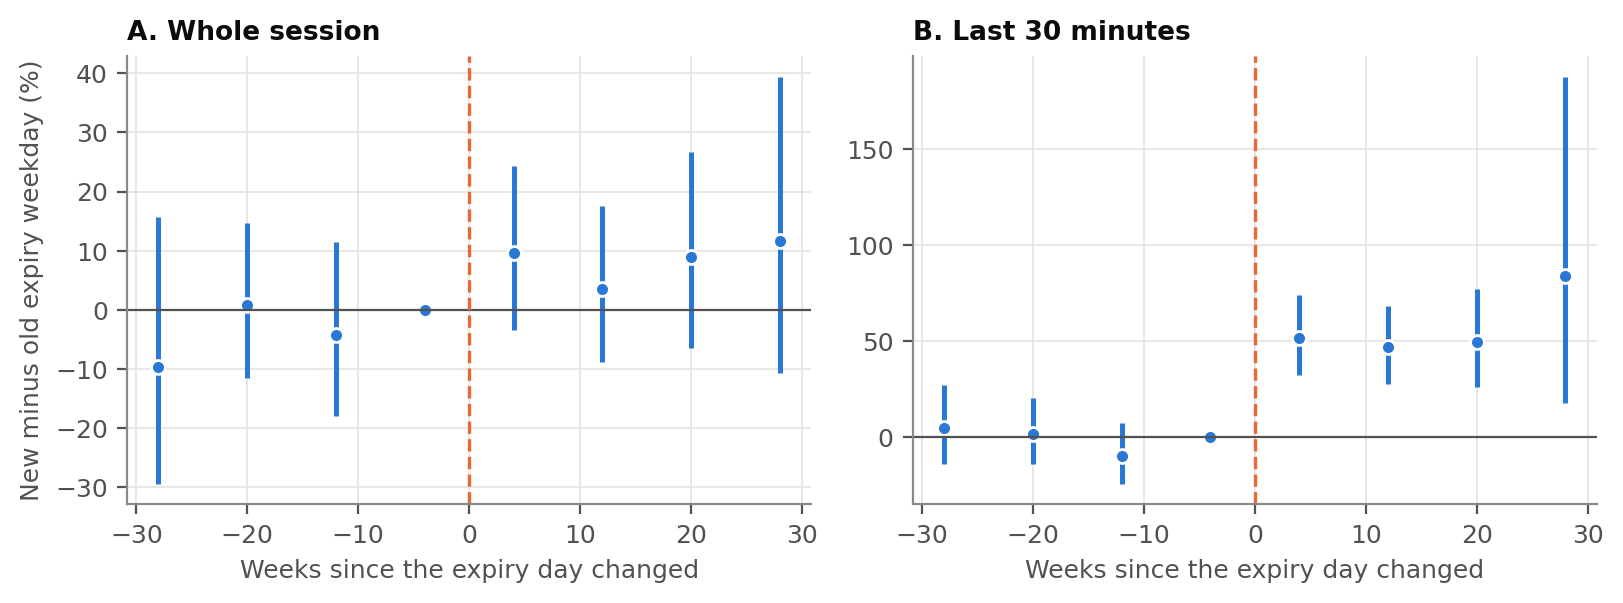

In [9]:
Image(FIG / 'fig5_event_time.png')

## Robustness checks
- The settlement-window result survives every check:
  - controlling for weekday patterns that change from year to year;
  - comparing indices on the same day;
  - different standard errors;
  - holiday controls;
  - placebo calendars.
- The whole-day result stays near zero, with one exception: measured against the mid-cap index, monthly expiry days look more volatile.

In [10]:
display(pd.read_csv(RES / 'robustness_lgk.csv').round(3))
pd.read_csv(RES / 'robustness_last30.csv').round(3)

,spec,term,coef,se,t,p,lo,hi,n
0,Baseline,own_weekly,-0.024,0.032,-0.744,0.457,-0.088,0.039,12312
1,Baseline,own_monthly,0.055,0.049,1.134,0.257,-0.040,0.151,12312
2,+ weekday x year effects,own_weekly,-0.025,0.039,-0.638,0.523,-0.101,0.052,12312
3,+ weekday x year effects,own_monthly,0.035,0.049,0.705,0.481,-0.062,0.131,12312
4,+ date effects (cross-index),own_weekly,0.034,0.034,1.007,0.314,-0.032,0.100,12312
5,+ date effects (cross-index),own_monthly,0.058,0.036,1.580,0.115,-0.014,0.129,12312
6,Driscoll-Kraay errors,own_weekly,-0.024,0.032,-0.758,0.448,-0.086,0.038,12312
7,Driscoll-Kraay errors,own_monthly,0.055,0.046,1.205,0.228,-0.035,0.145,12312
8,Without 2020,own_weekly,-0.008,0.034,-0.248,0.804,-0.075,0.058,11314
9,Without 2020,own_monthly,0.049,0.050,0.977,0.329,-0.050,0.149,11314


,spec,term,coef,se,t,p,lo,hi,n
0,Baseline,own_weekly,0.425,0.043,9.802,0.000,0.340,0.511,3428.0
1,Baseline,own_monthly,0.511,0.066,7.793,0.000,0.382,0.640,3428.0
2,+ weekday x year effects,own_weekly,0.450,0.063,7.130,0.000,0.325,0.574,3428.0
3,+ weekday x year effects,own_monthly,0.534,0.072,7.380,0.000,0.391,0.676,3428.0
4,+ date effects (cross-index),own_weekly,0.261,0.052,5.042,0.000,0.159,0.363,3428.0
5,+ date effects (cross-index),own_monthly,0.226,0.057,3.963,0.000,0.114,0.338,3428.0
6,Driscoll-Kraay errors,own_weekly,0.425,0.043,9.899,0.000,0.341,0.510,3428.0
7,Driscoll-Kraay errors,own_monthly,0.511,0.064,8.037,0.000,0.387,0.636,3428.0
8,+ holiday controls,own_weekly,0.406,0.042,9.555,0.000,0.322,0.489,3427.0
9,+ holiday controls,own_monthly,0.499,0.066,7.535,0.000,0.368,0.629,3427.0


## Placebo calendars (randomization inference)
- We pretend options expired on randomly chosen weekdays, keeping the real dates of every rule change, and redo the estimate 1,000 times.
- If expiry did nothing, the real estimate would look like a typical placebo estimate. It does for the whole day. For the last 30 minutes it is far outside the placebo range: none of the 1,000 placebos comes close.

,outcome,term,actual,placebo_mean,placebo_sd,ri_p,draws
0,lgk,own_weekly,-0.024,-0.019,0.031,0.484,1000
1,lgk,own_monthly,0.055,-0.004,0.043,0.218,1000
2,lrv_last,own_weekly,0.425,-0.002,0.123,0.001,1000
3,lrv_last,own_monthly,0.511,0.065,0.122,0.001,1000


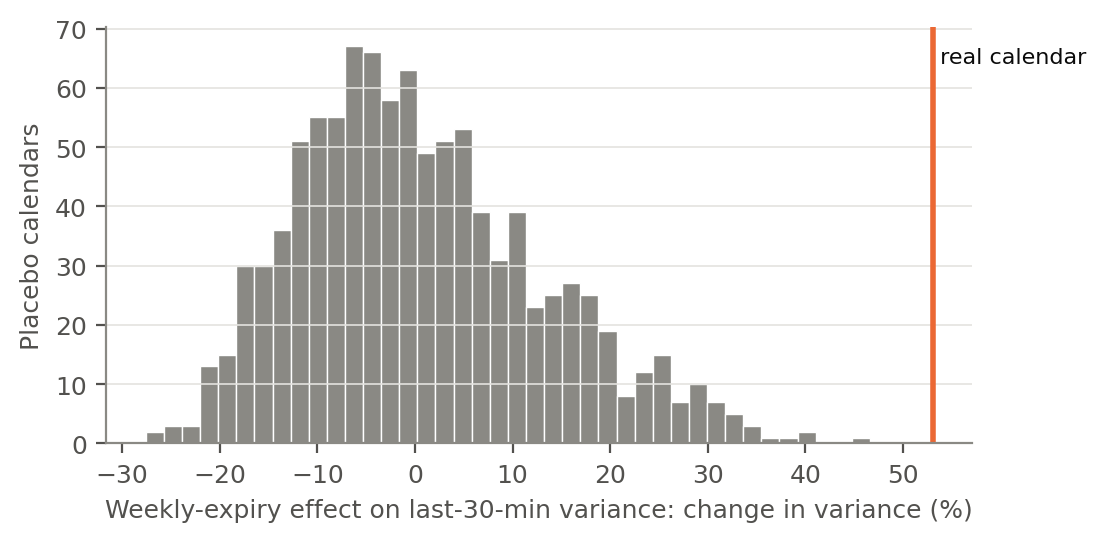

In [11]:
display(pd.read_csv(RES / 'randomization_inference.csv').round(3))
Image(FIG / 'figA2_placebo_last30.png')